In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
import contextily as ctx

from folium.plugins import HeatMap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

## Load Dataset

In [10]:
# menghubungkan colab dengan google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# memanggil data set lewat drive
df = pd.read_csv('/content/drive/MyDrive/NurulFikri/ML/Pertemuan11/data/wisata.csv')

In [19]:
# Menampilkan 5 baris pertama pada data
df.head()

,nama,kategori,kabupaten_kota,rating,preferensi,link_lokasi,latitude,longitude,link_gambar
0,Taman Mumbul Sangeh,Alam,Kabupaten Badung,4.6,Wisata Alam,https://www.google.com/maps/place/Taman+Mumbul...,-8.483959,115.212288,https://lh3.googleusercontent.com/p/AF1QipPniB...
1,Sangeh Monkey Forest,Alam,Kabupaten Badung,4.6,Wisata Alam,https://www.google.com/maps/place/Sangeh+Monke...,-8.481774,115.206739,https://lh3.googleusercontent.com/p/AF1QipN2_T...
2,Objek Wisata Sangeh,Umum,Kabupaten Badung,4.6,Wisata Umum,https://www.google.com/maps/place/Objek+Wisata...,-8.481566,115.206546,https://lh3.googleusercontent.com/p/AF1QipO1t7...
3,Satria Gatotkaca Park,Umum,Kabupaten Badung,4.6,Wisata Umum,https://www.google.com/maps/place/Satria+Gatot...,-8.744388,115.178867,https://lh3.googleusercontent.com/p/AF1QipP3kd...
4,Desa Wisata Penarungan,Umum,Kabupaten Badung,5.0,Wisata Umum,https://www.google.com/maps/place/Desa+Wisata+...,-8.539637,115.198893,https://lh3.googleusercontent.com/p/AF1QipO-JZ...


## Struktur Data

In [20]:
# Menampilkan informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nama            772 non-null    object 
 1   kategori        772 non-null    object 
 2   kabupaten_kota  772 non-null    object 
 3   rating          772 non-null    float64
 4   preferensi      772 non-null    object 
 5   link_lokasi     772 non-null    object 
 6   latitude        772 non-null    float64
 7   longitude       772 non-null    float64
 8   link_gambar     772 non-null    object 
dtypes: float64(3), object(6)
memory usage: 54.4+ KB


## Pengecekan Data

In [21]:
df.isnull().sum()

,0
nama,0
kategori,0
kabupaten_kota,0
rating,0
preferensi,0
link_lokasi,0
latitude,0
longitude,0
link_gambar,0


In [22]:
df.duplicated().sum()

np.int64(0)

## Visualisasi Lokasi Wisata dengan Peta Interaktif

In [25]:
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=11)

heat_data = df[['latitude','longitude']].dropna().values.tolist()
HeatMap(heat_data).add_to(m)

m

## Uji Normalitas dan Korelasi

In [26]:
numerics = df.select_dtypes(include=['float64','int64'])
from scipy.stats import shapiro

stat, p = shapiro(numerics)
print("p-value:", p)

p-value: 8.870510585344862e-56


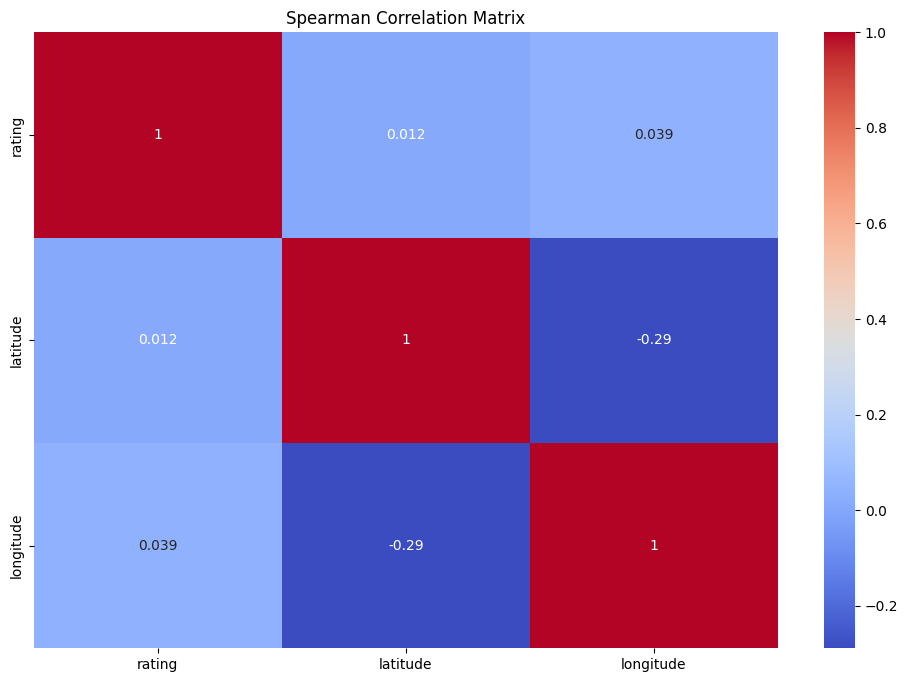

In [27]:
corr = numerics.corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Matrix")
plt.show()

## Data Preprocessing

In [31]:
from sklearn.preprocessing import RobustScaler
X = numerics.copy()

X = X.dropna()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,rating,latitude,longitude
0,0.122164,-0.147340,-0.019108
1,0.122164,-0.138065,-0.040429
2,0.122164,-0.137182,-0.041171
3,0.122164,-1.252997,-0.147517
4,1.455497,-0.383720,-0.070575


## Penentuan Parameter DBSCAN

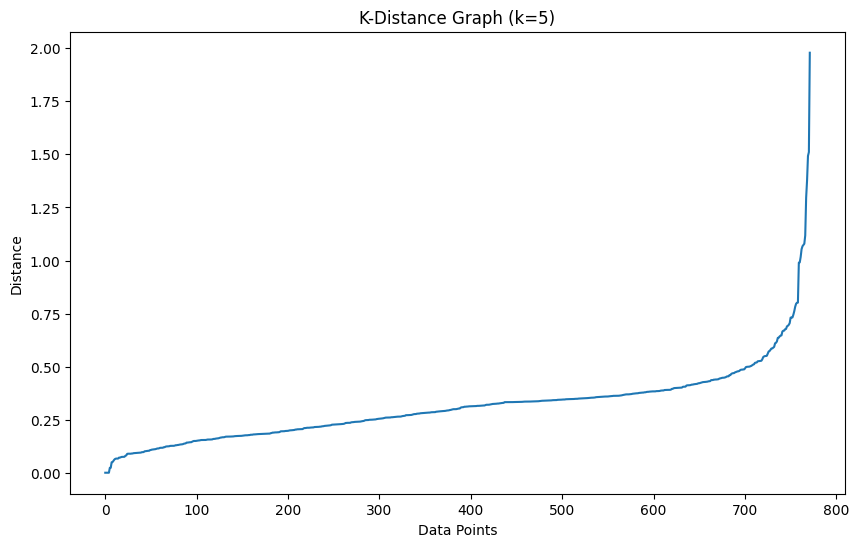

In [32]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph (k=5)")
plt.ylabel("Distance")
plt.xlabel("Data Points")
plt.show()

## Clustering dengan DBSCAN

In [33]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.35, min_samples=5)
db_labels = db.fit_predict(X_scaled)

cluster_series = pd.Series(db_labels, index=X.index)

df['Cluster'] = cluster_series
df['Cluster'].value_counts()

,count
Cluster,
0,553
-1,146
6,27
8,12
2,9
7,7
1,5
4,5
3,4


In [34]:
from sklearn.metrics import silhouette_score

non_noise_mask = db_labels != -1
X_for_silhouette = X_scaled[non_noise_mask]
labels_for_silhouette = db_labels[non_noise_mask]
sil = silhouette_score(X_for_silhouette, labels_for_silhouette)
sil

np.float64(-0.10103998506156703)

## Evaluasi Cluster

In [38]:
df['Cluster_Desc'] = df['Cluster'].map({
    0: "Baik",
    1: "Kurang",
    -1: "Noise"
})

df[['Cluster','Cluster_Desc']].head()

,Cluster,Cluster_Desc
0,0,Baik
1,0,Baik
2,0,Baik
3,0,Baik
4,2,NaN


In [39]:
summary = df.groupby('Cluster_Desc').mean(numeric_only=True)
summary

,rating,latitude,longitude,Cluster,PC1,PC2
Cluster_Desc,,,,,,
Baik,4.562050,-8.460704,115.267319,0.0,0.261511,0.084047
Kurang,4.020000,-8.766723,115.176859,1.0,0.204831,-1.861389
Noise,4.369863,-8.371217,115.101664,-1.0,-0.555620,-0.434990


## Visualisasi Hasil Clustering

In [41]:
import plotly.express as px

fig = px.scatter(
    df,
    x='PC1',
    y='PC2',
    color='Cluster_Desc',
    hover_data=['nama'],
    title="Visualisasi Hasil Clustering DBSCAN"
)
fig.show()